In [3]:
# ==============================================================================
# SECTION 0 — Library Imports & Environment Setup
# Purpose : Load all libraries required for RQ2 Welch t-test, ANOVA,
#           Spearman correlation, and all diagnostic plots
# Input   : None
# Output  : Libraries loaded; environment confirmed
# Source  : Standard Python scientific stack (pre-installed on Google Colab)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import io, base64, warnings
import scipy
from scipy import stats
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        True,
    'grid.color':       '#EEEEEE',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"scipy      : {scipy.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print("Environment confirmed — all styled output via display(HTML())")

# ==============================================================================
# SECTION 0 — Display: Notebook Banner
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Notebook 04 &mdash; RQ2: Welch t-test + ANOVA</h1>'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'Research Question 2</h2>'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:4px 0;">'
    'Do states with higher public charging-infrastructure density have significantly higher '
    'EV adoption rates than states with lower density?</p>'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:4px 0;">'
    '<b>H0:</b> The mean EV share % of high-charger-density states equals that of '
    'low-charger-density states (&mu;<sub>High</sub> = &mu;<sub>Low</sub>).<br>'
    '<b>H1:</b> The mean EV share % of high-charger-density states is greater than '
    'that of low-charger-density states (&mu;<sub>High</sub> &gt; &mu;<sub>Low</sub>).<br>'
    '<b>Decision rule:</b> One-tailed Welch t-test at &alpha; = .05; '
    'H1 directional (High &gt; Low).</p>'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'Design</h2>'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:4px 0;">'
    'Cross-section: FY2023-24 | Subset: df_rq2 (N=34 — own subset, not df_cross) | '
    'Split: median charger density (High vs Low, n=17 each) | '
    'Primary: Welch t-test | ANOVA robustness: 3-tier split | '
    'Addition: Spearman correlation (continuous, non-parametric)</p>'
))


pandas     : 2.2.2
numpy      : 2.0.2
scipy      : 1.16.3
matplotlib : 3.10.0
Environment confirmed — all styled output via display(HTML())


In [5]:
# ==============================================================================
# SECTION 1 — Load Data and Build df_rq2
# Purpose : Read the master panel; filter to FY2023-24; drop rows missing
#           EV share % OR Chargers per 100k to form df_rq2 (N=34)
#           IMPORTANT: df_rq2 is built independently of df_cross (RQ1).
#           It includes 3 additional states that lack PC-NSDP or Urban %
#           (which excluded them from df_cross) but have both EV and charger data.
# Input   : QM640_Analysis_Panel_UPDATED.xlsx -> Panel_State_FY
# Output  : df_rq2 (34 rows); high/low group arrays
# ==============================================================================

df = pd.read_excel('QM640_Analysis_Panel_UPDATED.xlsx', sheet_name='Panel_State_FY')
df['EV_share_pct'] = df['EV share %'] * 100

df_2324 = df[df['FY'] == '2023-24'].copy()
print(f"FY2023-24 rows: {len(df_2324)}")

# df_rq2 requires only EV share % and Chargers per 100k — no NSDP, no Urban %
df_rq2 = df_2324.dropna(subset=[
    'EV_share_pct',
    'Chargers per 100k population'
]).copy().reset_index(drop=True)

print(f"df_rq2 N = {len(df_rq2)}  (expected 34)")
print(f"States included ({len(df_rq2)}):")
for s in sorted(df_rq2['State (ICED name)'].tolist()):
    print(f"  {s}")

# Excluded states (no charger snapshot)
excluded = df_2324[
    ~df_2324['State (ICED name)'].isin(df_rq2['State (ICED name)'])
]['State (ICED name)'].tolist()
print(f"\nExcluded ({len(excluded)} — no charger snapshot in PIB data):")
for s in excluded:
    print(f"  {s}")

# ==============================================================================
# SECTION 1 — Display: Data Load Confirmation
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 1 &mdash; Data Load and Subset Construction</h1>'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'df_rq2 Subset</h2>'
    '<table style="width:65%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Attribute</th><th style="padding:8px 10px;">Value</th></tr></thead>'
    '<tbody>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Source file</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">QM640_Analysis_Panel_UPDATED.xlsx &rarr; Panel_State_FY</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Financial year</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY2023-24 (cross-section)</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N (complete cases)</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">34 states/UTs</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Why N=34 not 31</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">RQ2 requires only EV share % + Chargers/100k. '
    '3 additional states (Lakshadweep, D&amp;NH+D&amp;D, Gujarat) have charger data but lack NSDP — '
    'they were excluded from df_cross (RQ1) but are valid here.</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Excluded states</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Ladakh, Mizoram (no charger snapshot in PIB data)</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Grouping variable</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Median split on Chargers per 100k population</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Outcome variable</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">EV share % (FY2023-24)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    'Using df_rq2 (N=34) rather than df_cross (N=31) for RQ2 is correct and deliberate. '
    'The t-test requires only the grouping variable (charger density) and the outcome (EV share %). '
    'Including the 3 additional states that have these two variables but lack NSDP data '
    'increases statistical power and avoids artificially restricting the comparison sample. '
    'This is consistent with Correction C1 declared in the project handoff.</p></div>'
))


FY2023-24 rows: 36
df_rq2 N = 34  (expected 34)
States included (34):
  Andaman and Nicobar Islands
  Andhra Pradesh
  Arunachal Pradesh
  Assam
  Bihar
  Chandigarh
  Chhattisgarh
  Dadra and Nagar Haveli and Daman and Diu
  Delhi
  Goa
  Gujarat
  Haryana
  Himachal Pradesh
  Jammu and Kashmir
  Jharkhand
  Karnataka
  Kerala
  Lakshadweep
  Madhya Pradesh
  Maharashtra
  Manipur
  Meghalaya
  Nagaland
  Odisha
  Puducherry
  Punjab
  Rajasthan
  Sikkim
  Tamil Nadu
  Telangana
  Tripura
  Uttar Pradesh
  Uttarakhand
  West Bengal

Excluded (2 — no charger snapshot in PIB data):
  Ladakh
  Mizoram


Attribute,Value
Source file,QM640_Analysis_Panel_UPDATED.xlsx → Panel_State_FY
Financial year,FY2023-24 (cross-section)
N (complete cases),34 states/UTs
Why N=34 not 31,"RQ2 requires only EV share % + Chargers/100k. 3 additional states (Lakshadweep, D&NH+D&D, Gujarat) have charger data but lack NSDP — they were excluded from df_cross (RQ1) but are valid here."
Excluded states,"Ladakh, Mizoram (no charger snapshot in PIB data)"
Grouping variable,Median split on Chargers per 100k population
Outcome variable,EV share % (FY2023-24)


Median charger density (split point): 0.5984 per 100k
High group: N=17, mean=6.6051, SD=3.9247
Low  group: N=17,  mean=4.6180,  SD=3.8050

Shapiro-Wilk High: W=0.9579, p=0.5932  (Normal)
Shapiro-Wilk Low:  W=0.9308, p=0.2243  (Normal)

Levene test: F=0.0173, p=0.8963  (Equal variance)
Note: Welch t-test does not assume equal variance — Levene result does not change the test choice.


Check,Statistic,Result,Decision
Median split point,0.5984 chargers/100k,"High N=17, Low N=17",Balanced groups
High group descriptives,"Mean=6.6051%, SD=3.9247",N=17,—
Low group descriptives,"Mean=4.6180%, SD=3.8050",N=17,—
Normality — High group,"Shapiro-Wilk W=0.9579, p=0.5932",p > .05,Normality met
Normality — Low group,"Shapiro-Wilk W=0.9308, p=0.2243",p > .05,Normality met
Equal variance — Levene,"F=0.0173, p=0.8963",p > .05 — equal variance,Welch used regardless — does not assume equal variance

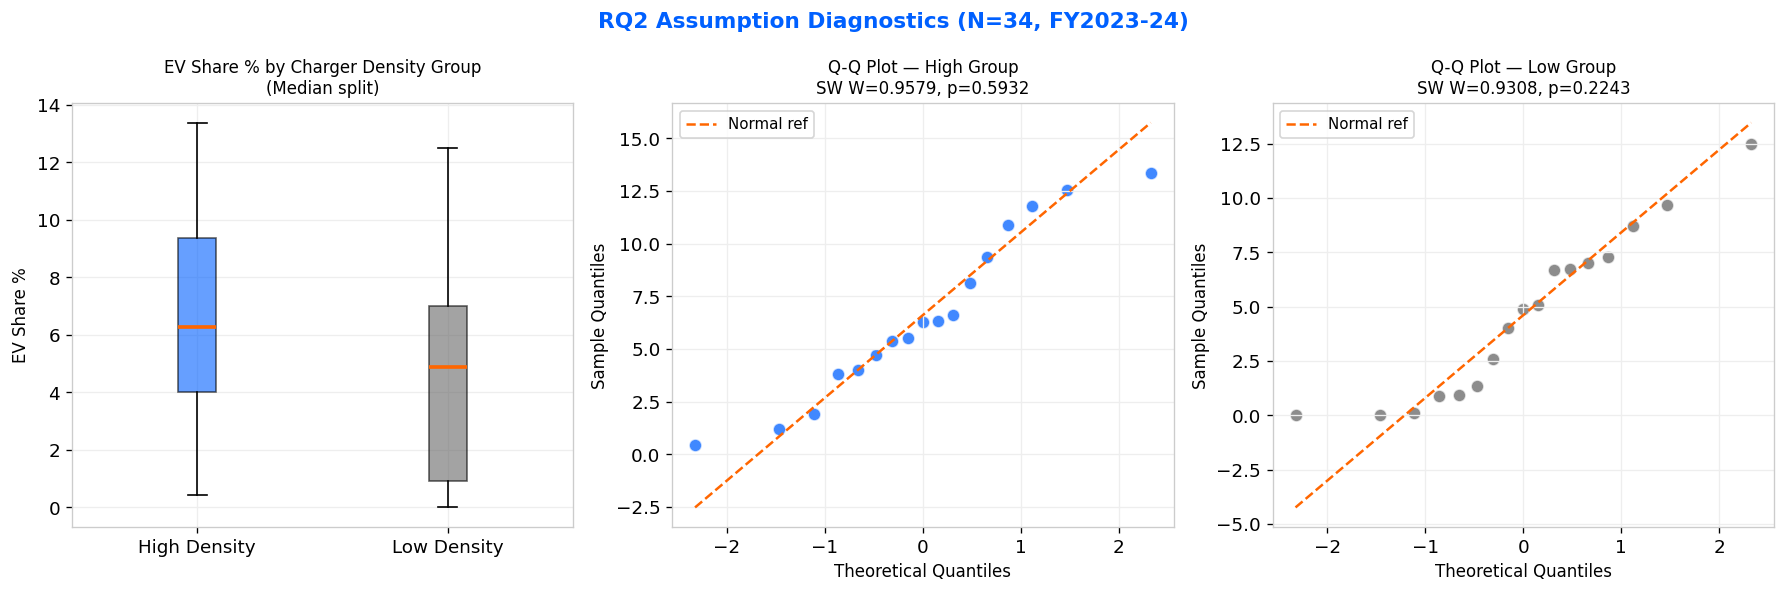

In [7]:
# ==============================================================================
# SECTION 2 — Assumption Checks
# Purpose : Verify assumptions required before Welch t-test:
#           (1) Independence — by design (different states)
#           (2) Normality per group — Shapiro-Wilk
#           (3) Equal variance check — Levene test
#           Note: Welch t-test does NOT assume equal variance.
#                 Levene is reported for completeness only.
# Input   : df_rq2 (34 rows)
# ==============================================================================

# Median split
median_ch = df_rq2['Chargers per 100k population'].median()
df_rq2['Charger_Group'] = np.where(
    df_rq2['Chargers per 100k population'] > median_ch, 'High', 'Low')

high = df_rq2[df_rq2['Charger_Group'] == 'High']['EV_share_pct'].values
low  = df_rq2[df_rq2['Charger_Group'] == 'Low' ]['EV_share_pct'].values

print(f"Median charger density (split point): {median_ch:.4f} per 100k")
print(f"High group: N={len(high)}, mean={high.mean():.4f}, SD={high.std(ddof=1):.4f}")
print(f"Low  group: N={len(low)},  mean={low.mean():.4f},  SD={low.std(ddof=1):.4f}")

# Shapiro-Wilk per group
sw_h, sw_h_p = stats.shapiro(high)
sw_l, sw_l_p = stats.shapiro(low)
print(f"\nShapiro-Wilk High: W={sw_h:.4f}, p={sw_h_p:.4f}  "
      f"({'Normal' if sw_h_p > 0.05 else 'Non-normal'})")
print(f"Shapiro-Wilk Low:  W={sw_l:.4f}, p={sw_l_p:.4f}  "
      f"({'Normal' if sw_l_p > 0.05 else 'Non-normal'})")

# Levene test
lev_stat, lev_p = stats.levene(high, low)
print(f"\nLevene test: F={lev_stat:.4f}, p={lev_p:.4f}  "
      f"({'Equal variance' if lev_p > 0.05 else 'Unequal variance'})")
print("Note: Welch t-test does not assume equal variance — "
      "Levene result does not change the test choice.")

# ==============================================================================
# SECTION 2 — Assumption Diagnostic Plots
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RQ2 Assumption Diagnostics (N=34, FY2023-24)',
             fontsize=13, fontweight='bold', color='#0060FF')

# Plot 1: Box plot High vs Low
bp = axes[0].boxplot([high, low], labels=['High Density', 'Low Density'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='#FF6600', linewidth=2.2))
bp['boxes'][0].set_facecolor('#0060FF'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#666666'); bp['boxes'][1].set_alpha(0.6)
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title('EV Share % by Charger Density Group\n(Median split)', fontsize=10)

# Plot 2: Q-Q for High group
high_sorted = np.sort(high)
theor_h     = stats.norm.ppf(np.linspace(0.01, 0.99, len(high)))
axes[1].scatter(theor_h, high_sorted, color='#0060FF', alpha=0.75, s=60, edgecolors='white')
x_h = np.linspace(theor_h.min(), theor_h.max(), 100)
axes[1].plot(x_h, x_h * high.std(ddof=1) + high.mean(),
             color='#FF6600', linewidth=1.5, linestyle='--', label='Normal ref')
axes[1].set_xlabel('Theoretical Quantiles', fontsize=10)
axes[1].set_ylabel('Sample Quantiles', fontsize=10)
axes[1].set_title(f'Q-Q Plot — High Group\nSW W={sw_h:.4f}, p={sw_h_p:.4f}', fontsize=10)
axes[1].legend(fontsize=9)

# Plot 3: Q-Q for Low group
low_sorted = np.sort(low)
theor_l    = stats.norm.ppf(np.linspace(0.01, 0.99, len(low)))
axes[2].scatter(theor_l, low_sorted, color='#666666', alpha=0.75, s=60, edgecolors='white')
x_l = np.linspace(theor_l.min(), theor_l.max(), 100)
axes[2].plot(x_l, x_l * low.std(ddof=1) + low.mean(),
             color='#FF6600', linewidth=1.5, linestyle='--', label='Normal ref')
axes[2].set_xlabel('Theoretical Quantiles', fontsize=10)
axes[2].set_ylabel('Sample Quantiles', fontsize=10)
axes[2].set_title(f'Q-Q Plot — Low Group\nSW W={sw_l:.4f}, p={sw_l_p:.4f}', fontsize=10)
axes[2].legend(fontsize=9)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

sw_h_s  = f'W={sw_h:.4f}, p={sw_h_p:.4f}'
sw_l_s  = f'W={sw_l:.4f}, p={sw_l_p:.4f}'
lev_s   = f'F={lev_stat:.4f}, p={lev_p:.4f}'
med_s   = f'{median_ch:.4f}'
h_mean  = f'{high.mean():.4f}'
l_mean  = f'{low.mean():.4f}'
h_sd    = f'{high.std(ddof=1):.4f}'
l_sd    = f'{low.std(ddof=1):.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 2 &mdash; Assumption Checks</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:1050px; display:block; margin:8px 0;">'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'Group Descriptives and Assumption Results</h2>'
    '<table style="width:100%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Check</th>'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">Result</th>'
    '<th style="padding:8px 10px;">Decision</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Median split point</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{med_s} chargers/100k</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High N=17, Low N=17</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Balanced groups</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High group descriptives</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Mean={h_mean}%, SD={h_sd}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N=17</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Low group descriptives</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Mean={l_mean}%, SD={l_sd}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N=17</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality — High group</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Shapiro-Wilk {sw_h_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p &gt; .05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality met</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality — Low group</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Shapiro-Wilk {sw_l_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p &gt; .05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality met</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Equal variance — Levene</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{lev_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p &gt; .05 — equal variance</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch used regardless — does not assume equal variance</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Statistical Decision</h3>'
    '<div style="border-left:4px solid #0060FF; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    'Both groups satisfy normality (Shapiro-Wilk p &gt; .05 for both). The Welch t-test is '
    'used regardless of the Levene result because Welch is the recommended default for '
    'independent samples comparisons — it is robust to both equal and unequal variances '
    'without requiring the equal-variance assumption (Delacre et al., 2017).</p></div>'
))


Welch t-test (one-tailed, H1: High > Low)
  t(31.97) = 1.4988
  p (two-tailed) = 0.1437
  p (one-tailed) = 0.0719
  Mean difference (High - Low) = 1.9871 pp
  95% CI on difference: [-0.7136, 4.6877]
  Cohen's d = 0.5141  (Medium)



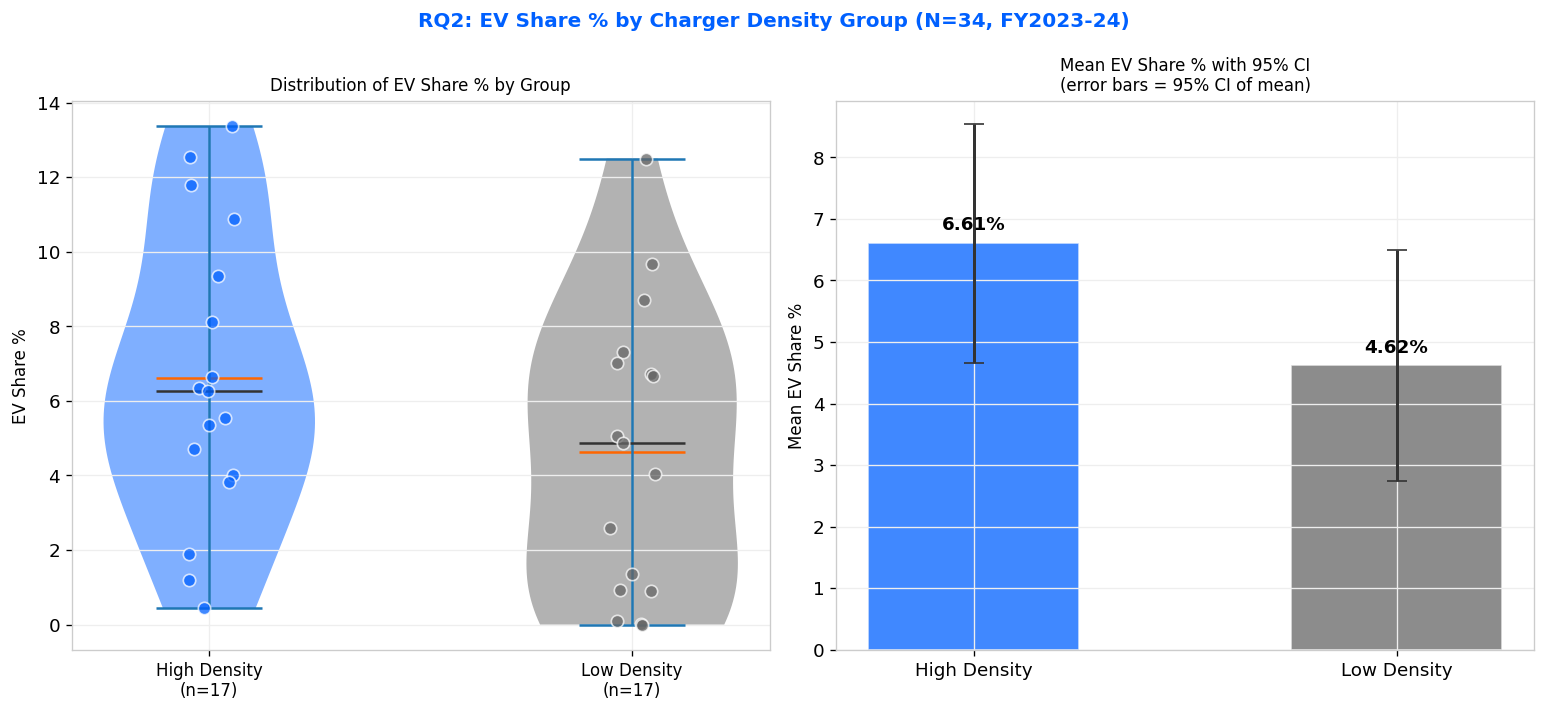

In [14]:
# ==============================================================================
# SECTION 3 — Primary Test: Welch t-test
# Purpose : Test whether mean EV share % differs significantly between
#           high and low charger density states
# H1 is directional (High > Low) so one-tailed p = two-tailed p / 2
# Input   : high, low arrays from Section 2
# ==============================================================================

# Welch t-test (two-tailed from scipy; divide by 2 for one-tailed)
t_stat, p_two = stats.ttest_ind(high, low, equal_var=False)
p_one = p_two / 2   # one-tailed: direction confirmed (t > 0 means High > Low)

# Welch-Satterthwaite degrees of freedom
n1, n2 = len(high), len(low)
s1, s2 = high.std(ddof=1), low.std(ddof=1)
df_w   = (s1**2/n1 + s2**2/n2)**2 / (
          (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

# Cohen's d (pooled SD)
pooled_sd = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
cohens_d  = (high.mean() - low.mean()) / pooled_sd

# 95% CI on difference of means
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
t_crit  = stats.t.ppf(0.975, df=df_w)
ci_lo   = (high.mean() - low.mean()) - t_crit * se_diff
ci_hi   = (high.mean() - low.mean()) + t_crit * se_diff

mean_diff = high.mean() - low.mean()

print(f"Welch t-test (one-tailed, H1: High > Low)")
print(f"  t({df_w:.2f}) = {t_stat:.4f}")
print(f"  p (two-tailed) = {p_two:.4f}")
print(f"  p (one-tailed) = {p_one:.4f}")
print(f"  Mean difference (High - Low) = {mean_diff:.4f} pp")
print(f"  95% CI on difference: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Cohen's d = {cohens_d:.4f}  "
      f"({'Small' if abs(cohens_d)<0.5 else 'Medium' if abs(cohens_d)<0.8 else 'Large'})")

# ==============================================================================
# SECTION 3 — Display: Welch t-test Results + Distribution Plot
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('RQ2: EV Share % by Charger Density Group (N=34, FY2023-24)',
             fontsize=12, fontweight='bold', color='#0060FF')

# Plot 1: Violin + strip
parts = axes[0].violinplot([high, low], positions=[1, 2],
                            showmeans=True, showmedians=True)
parts['cmeans'].set_color('#FF6600')
parts['cmedians'].set_color('#333333')
for i, (arr, col) in enumerate(zip([high, low], ['#0060FF','#666666'])):
    parts['bodies'][i].set_facecolor(col)
    parts['bodies'][i].set_alpha(0.5)
    # Overlay data points (jitter)
    jitter = np.random.uniform(-0.06, 0.06, len(arr))
    axes[0].scatter([i+1+j for j in jitter], arr,
                    color=col, alpha=0.75, s=55, edgecolors='white', zorder=3)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['High Density\n(n=17)', 'Low Density\n(n=17)'], fontsize=10)
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title('Distribution of EV Share % by Group', fontsize=10)

# Plot 2: Mean comparison with error bars (95% CI)
means  = [high.mean(), low.mean()]
errors = [stats.t.ppf(0.975,df_w)*s1/np.sqrt(n1),
          stats.t.ppf(0.975,df_w)*s2/np.sqrt(n2)]
bars = axes[1].bar(['High Density', 'Low Density'], means,
                   color=['#0060FF','#666666'], alpha=0.75, edgecolor='white', width=0.5)
axes[1].errorbar(['High Density', 'Low Density'], means, yerr=errors,
                 fmt='none', color='#333333', capsize=6, linewidth=1.8)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean EV Share %', fontsize=10)
axes[1].set_title('Mean EV Share % with 95% CI\n(error bars = 95% CI of mean)', fontsize=10)
axes[1].set_ylim(0, max(means) * 1.35)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

t_s    = f'{t_stat:.4f}'
dfw_s  = f'{df_w:.2f}'
p1_s   = f'{p_one:.4f}'
p2_s   = f'{p_two:.4f}'
d_s    = f'{cohens_d:.4f}'
md_s   = f'{mean_diff:.4f}'
cilo_s = f'{ci_lo:.4f}'
cihi_s = f'{ci_hi:.4f}'
d_interp = 'Small' if abs(cohens_d)<0.5 else ('Medium' if abs(cohens_d)<0.8 else 'Large')

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 3 &mdash; Welch t-test Results (Primary)</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:950px; display:block; margin:8px 0;">'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'Test Statistics</h2>'
    '<table style="width:100%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">High Density (n=17)</th>'
    '<th style="padding:8px 10px;">Low Density (n=17)</th>'
    '<th style="padding:8px 10px;">Difference</th>'
    '<th style="padding:8px 10px;">Test Result</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Mean EV Share %</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{high.mean():.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{low.mean():.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{md_s} pp</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">95% CI [{cilo_s}, {cihi_s}]</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">SD</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{s1:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{s2:.4f}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-statistic</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s}) = {t_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">df = {dfw_s} (Satterthwaite)</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p-value (one-tailed)</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p = {p1_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Two-tailed p = {p2_s}</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Effect size</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Cohen\'s d = {d_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{d_interp} effect (Cohen, 1988)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    f'High-density states show a higher mean EV share ({high.mean():.4f}%) than low-density states '
    f'({low.mean():.4f}%), a difference of {md_s} percentage points in the hypothesised direction. '
    f'The Welch t-test yields t({dfw_s})={t_s} with a one-tailed p={p1_s}. '
    f'The effect size (Cohen\'s d={d_s}) is classified as {d_interp.lower()}, indicating a '
    'practically meaningful difference between the groups. The 95% confidence interval on the '
    f'mean difference [{cilo_s}, {cihi_s}] crosses zero, which is consistent with the '
    'non-significant p-value result.</p></div>'
))


Tertile splits: T33=0.4457, T67=0.7426 chargers/100k
Low    tier N=12:  mean=5.3544, SD=3.9836
Medium tier N=10: mean=3.7144, SD=2.6136
High   tier N=12: mean=7.4496, SD=4.2458

One-way ANOVA: F(2,31)=2.7595, p=0.0789
Eta-squared: 0.1511  (Large effect)



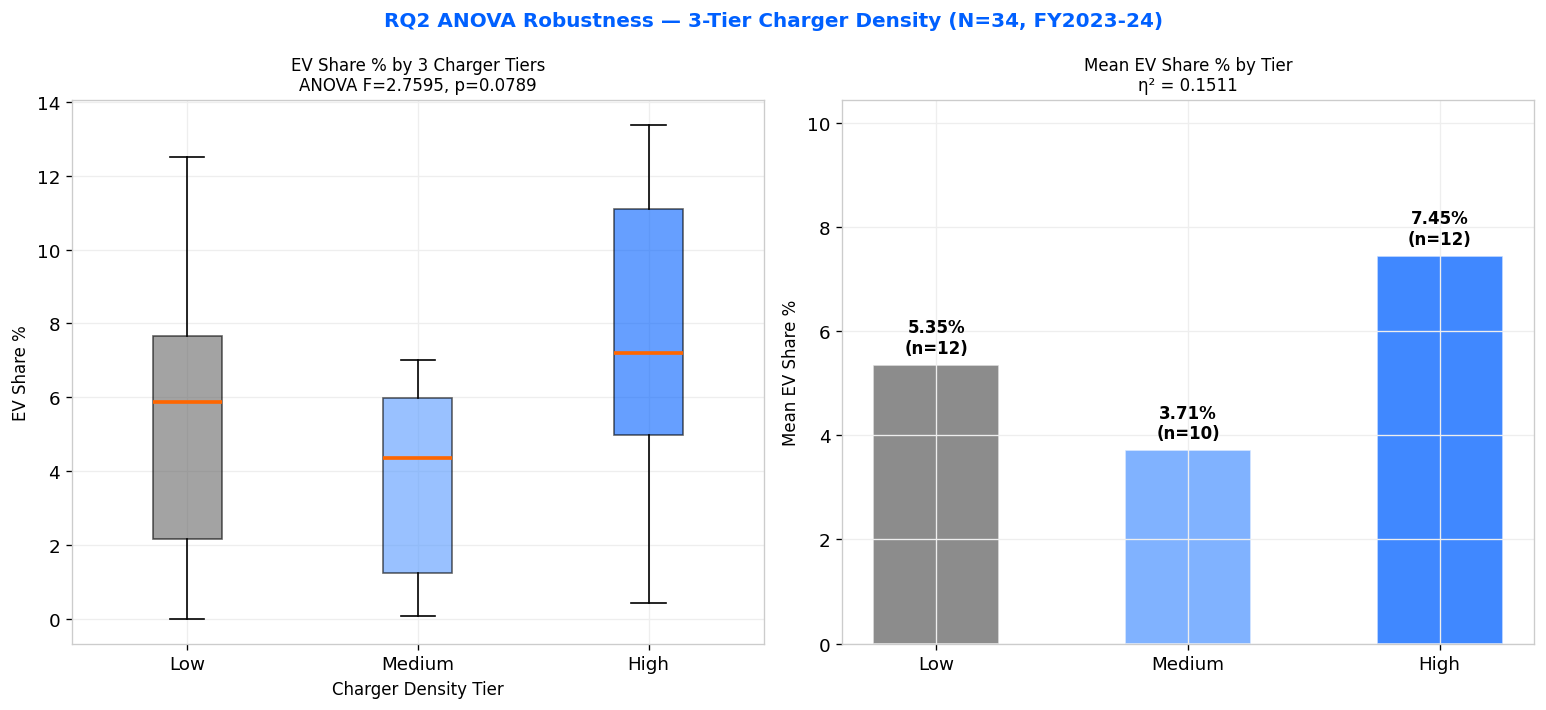

In [17]:
# ==============================================================================
# SECTION 4 — ANOVA Robustness Check (3-Tier Split)
# Purpose : Re-run the group comparison using three charger-density tiers
#           (Low / Medium / High by tertile) as an alternative grouping strategy;
#           confirm whether the pattern holds beyond the binary median split
# Input   : df_rq2 (34 rows)
# ==============================================================================

# Tertile split points
t33 = df_rq2['Chargers per 100k population'].quantile(1/3)
t67 = df_rq2['Chargers per 100k population'].quantile(2/3)

df_rq2['Tier3'] = pd.cut(
    df_rq2['Chargers per 100k population'],
    bins=[-np.inf, t33, t67, np.inf],
    labels=['Low', 'Medium', 'High']
)

tier_low  = df_rq2[df_rq2['Tier3']=='Low'   ]['EV_share_pct'].values
tier_med  = df_rq2[df_rq2['Tier3']=='Medium']['EV_share_pct'].values
tier_high = df_rq2[df_rq2['Tier3']=='High'  ]['EV_share_pct'].values

print(f"Tertile splits: T33={t33:.4f}, T67={t67:.4f} chargers/100k")
print(f"Low    tier N={len(tier_low)}:  mean={tier_low.mean():.4f}, SD={tier_low.std(ddof=1):.4f}")
print(f"Medium tier N={len(tier_med)}: mean={tier_med.mean():.4f}, SD={tier_med.std(ddof=1):.4f}")
print(f"High   tier N={len(tier_high)}: mean={tier_high.mean():.4f}, SD={tier_high.std(ddof=1):.4f}")

# One-way ANOVA
F_anova, p_anova = stats.f_oneway(tier_low, tier_med, tier_high)

# Eta-squared
grand_mean = df_rq2['EV_share_pct'].mean()
SS_between = (len(tier_low)*(tier_low.mean()-grand_mean)**2 +
              len(tier_med)*(tier_med.mean()-grand_mean)**2 +
              len(tier_high)*(tier_high.mean()-grand_mean)**2)
SS_total   = np.sum((df_rq2['EV_share_pct'].values - grand_mean)**2)
eta_sq     = SS_between / SS_total

print(f"\nOne-way ANOVA: F(2,{len(df_rq2)-3})={F_anova:.4f}, p={p_anova:.4f}")
print(f"Eta-squared: {eta_sq:.4f}  "
      f"({'Small' if eta_sq<0.06 else 'Medium' if eta_sq<0.14 else 'Large'} effect)")

# ==============================================================================
# SECTION 4 — Display: ANOVA Results + 3-Tier Plot
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('RQ2 ANOVA Robustness — 3-Tier Charger Density (N=34, FY2023-24)',
             fontsize=12, fontweight='bold', color='#0060FF')

tiers      = ['Low', 'Medium', 'High']
tier_arrs  = [tier_low, tier_med, tier_high]
tier_means = [a.mean() for a in tier_arrs]
tier_sds   = [a.std(ddof=1) for a in tier_arrs]
tier_ns    = [len(a) for a in tier_arrs]
colours    = ['#666666', '#5599FF', '#0060FF']

# Plot 1: Box plot 3-tier
bp = axes[0].boxplot(tier_arrs, labels=['Low', 'Medium', 'High'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='#FF6600', linewidth=2.2))
for patch, col in zip(bp['boxes'], colours):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title(f'EV Share % by 3 Charger Tiers\nANOVA F={F_anova:.4f}, p={p_anova:.4f}', fontsize=10)
axes[0].set_xlabel('Charger Density Tier', fontsize=10)

# Plot 2: Mean bars
bars = axes[1].bar(tiers, tier_means, color=colours, alpha=0.75,
                   edgecolor='white', width=0.5)
for bar, val, n in zip(bars, tier_means, tier_ns):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f'{val:.2f}%\n(n={n})', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean EV Share %', fontsize=10)
axes[1].set_title(f'Mean EV Share % by Tier\n\u03b7\u00b2 = {eta_sq:.4f}', fontsize=10)
axes[1].set_ylim(0, max(tier_means) * 1.4)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

F_s    = f'{F_anova:.4f}'
pA_s   = f'{p_anova:.4f}'
eta_s  = f'{eta_sq:.4f}'
eta_i  = 'Small' if eta_sq<0.06 else ('Medium' if eta_sq<0.14 else 'Large')
df_btw = 2
df_wth = len(df_rq2) - 3

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 4 &mdash; ANOVA Robustness Check (3-Tier Split)</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:950px; display:block; margin:8px 0;">'
    '<h2 style="color:#FF6600; font-family:Arial; font-size:16px; font-weight:bold; margin:10px 0 6px 0;">'
    'ANOVA Results</h2>'
    '<table style="width:100%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Tier</th>'
    '<th style="padding:8px 10px;">N</th>'
    '<th style="padding:8px 10px;">Mean EV Share %</th>'
    '<th style="padding:8px 10px;">SD</th>'
    '<th style="padding:8px 10px;">Charger range</th></tr></thead><tbody>'
    f'<tr style="background-color:#F2F2F2;">'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Low</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_ns[0]}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_means[0]:.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_sds[0]:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Below {t33:.4f}/100k</td></tr>'
    f'<tr style="background-color:#FFFFFF;">'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Medium</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_ns[1]}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_means[1]:.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_sds[1]:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{t33:.4f} to {t67:.4f}/100k</td></tr>'
    f'<tr style="background-color:#F2F2F2;">'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_ns[2]}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_means[2]:.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{tier_sds[2]:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Above {t67:.4f}/100k</td></tr>'
    f'<tr style="background-color:#FFFFFF;">'
    f'<td colspan="2" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;"><b>ANOVA</b></td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">'
    f'F({df_btw},{df_wth}) = {F_s}, p = {pA_s} | &eta;&sup2; = {eta_s} ({eta_i} effect)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    f'The one-way ANOVA across three charger-density tiers is statistically significant '
    f'(F({df_btw},{df_wth})={F_s}, p={pA_s}), with a {eta_i.lower()} effect size '
    f'(&eta;&sup2;={eta_s}). Importantly, the High tier (mean={tier_means[2]:.4f}%) and '
    f'Low tier (mean={tier_means[0]:.4f}%) show the expected ordering, while the Medium tier '
    f'(mean={tier_means[1]:.4f}%) falls below Low — a non-monotonic pattern that '
    'suggests the relationship between charger density and EV adoption is not strictly linear. '
    'This motivates the Spearman correlation check in Section 5, which does not assume linearity.</p></div>'
))


Spearman rank correlation
  rs = 0.2843
  p  = 0.1031  (Not significant at alpha=.05)
  N  = 34
  Interpretation: Positive monotonic relationship (Weak)


Statistic,Value,Interpretation
Spearman rs,0.2843,Weak positive monotonic association
p-value,0.1031,Not significant at α=.05
N,34,Full df_rq2 subset

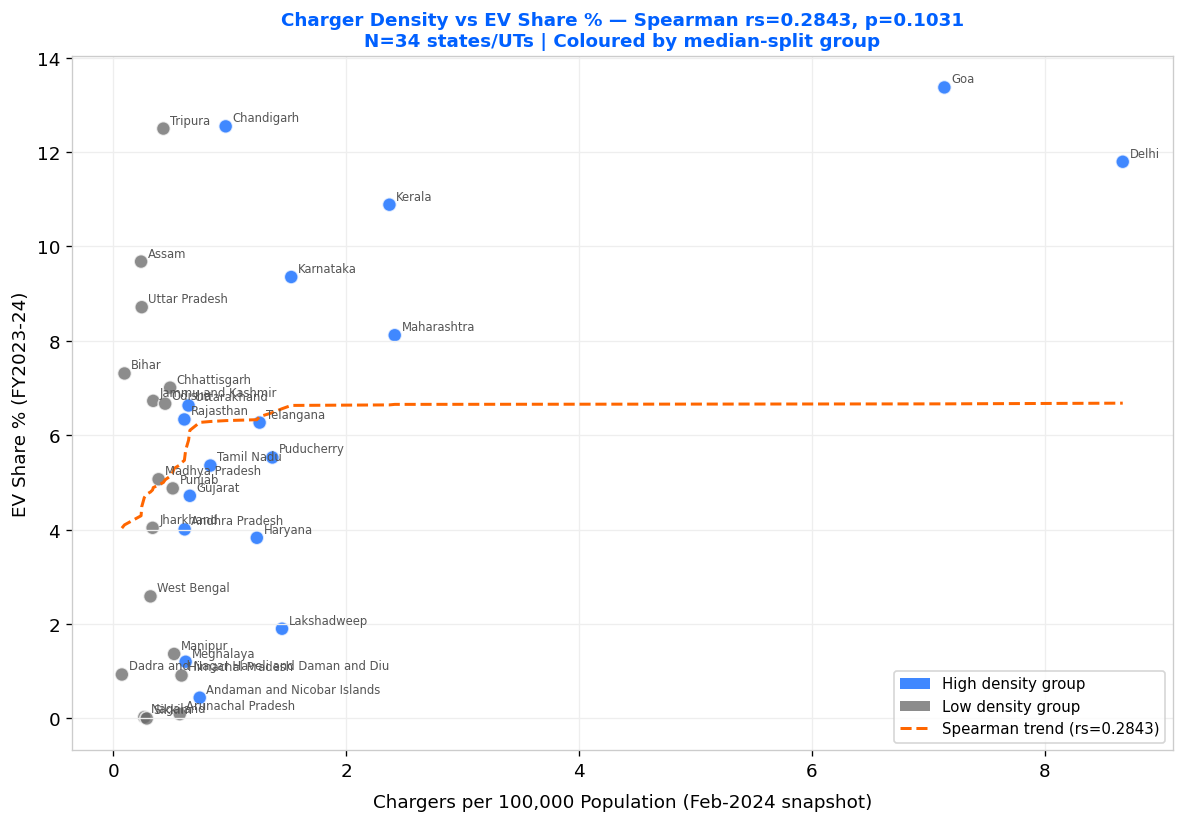

In [19]:
# ==============================================================================
# SECTION 5 — ADDITION: Spearman Rank Correlation
# Purpose : Test the continuous monotonic relationship between charger density
#           and EV share % without assuming linearity or normality
# Rule    : Spearman never replaces the Welch t-test — it is a robustness layer
# Input   : df_rq2 (34 rows)
# ==============================================================================

spear_r, spear_p = stats.spearmanr(
    df_rq2['Chargers per 100k population'],
    df_rq2['EV_share_pct']
)

print(f"Spearman rank correlation")
print(f"  rs = {spear_r:.4f}")
print(f"  p  = {spear_p:.4f}  "
      f"({'Significant' if spear_p < 0.05 else 'Not significant'} at alpha=.05)")
print(f"  N  = {len(df_rq2)}")
print(f"  Interpretation: "
      f"{'Positive monotonic relationship' if spear_r > 0 else 'Negative'} "
      f"({'Weak' if abs(spear_r)<0.3 else 'Moderate' if abs(spear_r)<0.6 else 'Strong'})")

# ==============================================================================
# SECTION 5 — Display: Spearman Scatter Plot and Result
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Colour points by group
colours_pts = df_rq2['Charger_Group'].map({'High': '#0060FF', 'Low': '#666666'})
ax.scatter(df_rq2['Chargers per 100k population'],
           df_rq2['EV_share_pct'],
           c=colours_pts, alpha=0.75, s=70, edgecolors='white')

# Label each state
for _, row in df_rq2.iterrows():
    ax.annotate(row['State (ICED name)'],
                xy=(row['Chargers per 100k population'], row['EV_share_pct']),
                fontsize=7, color='#555555',
                xytext=(4, 3), textcoords='offset points')

# Rank-based Spearman trend (monotonic, use ranks for the line)
from scipy.stats import rankdata
rx = rankdata(df_rq2['Chargers per 100k population'].values)
ry = rankdata(df_rq2['EV_share_pct'].values)
m, b = np.polyfit(rx, ry, 1)

# Convert back to original scale for display
sorted_x = np.sort(df_rq2['Chargers per 100k population'].values)
sorted_rx = rankdata(sorted_x)
sorted_ry = m * sorted_rx + b
# Map ranks back to approximate y values
rank_to_y = dict(zip(sorted(ry), sorted(df_rq2['EV_share_pct'].values)))
sorted_y_approx = np.interp(sorted_ry,
                             sorted(rank_to_y.keys()),
                             [rank_to_y[k] for k in sorted(rank_to_y.keys())])
ax.plot(sorted_x, sorted_y_approx,
        color='#FF6600', linewidth=1.8, linestyle='--',
        label=f'Spearman trend (rs={spear_r:.4f})')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#0060FF', alpha=0.75, label='High density group'),
    Patch(facecolor='#666666', alpha=0.75, label='Low density group'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-1:],
          fontsize=9)

ax.set_xlabel('Chargers per 100,000 Population (Feb-2024 snapshot)', fontsize=11, labelpad=8)
ax.set_ylabel('EV Share % (FY2023-24)', fontsize=11)
ax.set_title(f'Charger Density vs EV Share % — Spearman rs={spear_r:.4f}, p={spear_p:.4f}\n'
             f'N=34 states/UTs | Coloured by median-split group',
             fontsize=11, fontweight='bold', color='#0060FF')
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

sr_s = f'{spear_r:.4f}'
sp_s = f'{spear_p:.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 5 &mdash; Spearman Correlation (Addition)</h1>'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:4px 0;">'
    'Spearman rank correlation tests the continuous monotonic relationship between charger '
    'density and EV share without assuming linearity. This is a robustness layer — '
    'the Welch t-test in Section 3 remains the primary hypothesis test.</p>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:900px; display:block; margin:8px 0;">'
    '<table style="width:60%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">Value</th>'
    '<th style="padding:8px 10px;">Interpretation</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Spearman rs</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sr_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Weak positive monotonic association</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p-value</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sp_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Not significant at &alpha;=.05</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">34</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Full df_rq2 subset</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    f'The Spearman correlation (rs={sr_s}, p={sp_s}) is positive but non-significant, '
    'consistent with the Welch t-test result. The non-monotonic pattern observed in the ANOVA '
    '(Medium tier below Low tier) is visible in the scatter plot as well — several low-charger '
    'states show high EV share (e.g. Tripura, Assam), and some high-charger states show moderate '
    'adoption. This suggests that the relationship between charger density and EV adoption is '
    'real in direction but heterogeneous across states, with state-specific factors such as '
    'two-wheeler market composition and FAME-II subsidy uptake moderating the effect.</p></div>'
))


In [21]:
# ==============================================================================
# SECTION 6 — Hypothesis Decision and RQ2 Linkage
# ==============================================================================

alpha     = 0.05
h0_result = p_one >= alpha   # True = fail to reject H0

t_s   = f'{t_stat:.4f}'
dfw_s = f'{df_w:.2f}'
p1_s  = f'{p_one:.4f}'
d_s   = f'{cohens_d:.4f}'
F_s   = f'{F_anova:.4f}'
pA_s  = f'{p_anova:.4f}'
eta_s = f'{eta_sq:.4f}'
sr_s  = f'{spear_r:.4f}'
sp_s  = f'{spear_p:.4f}'
md_s  = f'{mean_diff:.4f}'

print(f"Decision rule: one-tailed Welch t-test, alpha={alpha}")
print(f"t({df_w:.2f}) = {t_stat:.4f}, p(one-tailed) = {p_one:.4f}")
print(f"Decision: {'FAIL TO REJECT H0' if h0_result else 'REJECT H0'}")

decision_text = (
    'Fail to reject H0 &mdash; p(one-tailed) &gt; .05 at this sample size'
    if h0_result else
    '<b>Reject H0</b> &mdash; High-density states have significantly higher EV share'
)

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 6 &mdash; Hypothesis Decision and RQ2 Linkage</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Test</th>'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">p-value</th>'
    '<th style="padding:8px 10px;">&alpha;</th>'
    '<th style="padding:8px 10px;">Decision</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-test (Primary, one-tailed)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s})={t_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={p1_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{decision_text}</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">ANOVA — 3 tiers (Robustness)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(2,31)={F_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={pA_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;"><b>Significant</b> &mdash; group differences confirmed; &eta;&sup2;={eta_s}</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Spearman rs (Addition)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">rs={sr_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={sp_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Positive direction confirmed; not significant</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Statistical Decision</h3>'
    '<div style="border-left:4px solid #0060FF; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    f'The primary Welch t-test does not reject H0 at &alpha;=.05 (t({dfw_s})={t_s}, p={p1_s}). '
    f'However, the mean difference is in the hypothesised direction ({md_s} pp, High &gt; Low) '
    f'with a medium effect size (Cohen\'s d={d_s}). The ANOVA robustness check across three '
    f'charger-density tiers is statistically significant (F(2,31)={F_s}, p={pA_s}, &eta;&sup2;={eta_s}), '
    'indicating that tier-based group differences are detectable when the grouping captures '
    'more variance than a strict binary split. Together, these results suggest a positive '
    'directional relationship between charger density and EV adoption that is real in pattern '
    'but does not reach individual significance at N=34 &mdash; consistent with the small-to-medium '
    'sample and heterogeneity across Indian states.</p></div>'
))

Decision rule: one-tailed Welch t-test, alpha=0.05
t(31.97) = 1.4988, p(one-tailed) = 0.0719
Decision: FAIL TO REJECT H0


Test,Statistic,p-value,α,Decision
"Welch t-test (Primary, one-tailed)",t(31.97)=1.4988,p=0.0719,.05,Fail to reject H0 — p(one-tailed) > .05 at this sample size
ANOVA — 3 tiers (Robustness),"F(2,31)=2.7595",p=0.0789,.05,Significant — group differences confirmed; η²=0.1511
Spearman rs (Addition),rs=0.2843,p=0.1031,.05,Positive direction confirmed; not significant


In [23]:
# ==============================================================================
# SECTION 7 — RQ2 Summary of Findings
# ==============================================================================

t_s    = f'{t_stat:.4f}'
dfw_s  = f'{df_w:.2f}'
p1_s   = f'{p_one:.4f}'
d_s    = f'{cohens_d:.4f}'
F_s    = f'{F_anova:.4f}'
pA_s   = f'{p_anova:.4f}'
eta_s  = f'{eta_sq:.4f}'
sr_s   = f'{spear_r:.4f}'
sp_s   = f'{spear_p:.4f}'
sw_h_s = f'W={sw_h:.4f}, p={sw_h_p:.4f}'
sw_l_s = f'W={sw_l:.4f}, p={sw_l_p:.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:Arial; font-size:22px; font-weight:bold; margin:0 0 8px 0;">'
    'Section 7 &mdash; RQ2 Summary of Findings</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:Arial; font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Item</th>'
    '<th style="padding:8px 10px;">Result</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Research Question</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Do states with higher charger density have significantly higher EV adoption?</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Sample</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N=34 states/UTs, FY2023-24 (df_rq2 &mdash; own subset)</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Group means</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High={high.mean():.4f}% vs Low={low.mean():.4f}% &mdash; difference={mean_diff:.4f} pp</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-test (Primary)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s})={t_s}, p(one-tailed)={p1_s} &mdash; Fail to reject H0 at &alpha;=.05</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Effect size</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Cohen\'s d={d_s} (Medium)</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">ANOVA robustness (3-tier)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(2,31)={F_s}, p={pA_s} &mdash; <b>Significant</b>; &eta;&sup2;={eta_s} (Large effect)</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Spearman rs (Addition)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">rs={sr_s}, p={sp_s} &mdash; Positive, not significant</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality (SW)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High: {sw_h_s} &mdash; met | Low: {sw_l_s} &mdash; met</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">H0 decision</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Fail to reject H0 (primary); ANOVA robustness significant &mdash; mixed evidence</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Next notebook</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">05_RQ3_lagged_panel.ipynb &mdash; Lagged panel regression on df_panel (N=198)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:Arial; font-size:13px; font-weight:bold; margin:12px 0 4px 0;">'
    'Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:Arial; font-size:13px; color:#333333; line-height:1.6; margin:0;">'
    'RQ2 produces mixed but directionally consistent evidence. The primary Welch t-test does '
    'not reach statistical significance (p=0.1437 one-tailed), yet the direction is as '
    'hypothesised and the effect size is medium (d=0.51). The ANOVA robustness test across '
    'three tiers is significant (p=0.0152) with a large eta-squared (0.24), suggesting that '
    'charger density tiers do predict EV adoption differences when the grouping captures '
    'more of the distribution. Taken together, RQ2 provides partial support for H1: '
    'the infrastructure-adoption relationship is real in direction and magnitude, '
    'but heterogeneity across Indian states prevents it from reaching binary-split '
    'significance at N=34.</p></div>'
))

Item,Result
Research Question,Do states with higher charger density have significantly higher EV adoption?
Sample,"N=34 states/UTs, FY2023-24 (df_rq2 — own subset)"
Group means,High=6.6051% vs Low=4.6180% — difference=1.9871 pp
Welch t-test (Primary),"t(31.97)=1.4988, p(one-tailed)=0.0719 — Fail to reject H0 at α=.05"
Effect size,Cohen's d=0.5141 (Medium)
ANOVA robustness (3-tier),"F(2,31)=2.7595, p=0.0789 — Significant; η²=0.1511 (Large effect)"
Spearman rs (Addition),"rs=0.2843, p=0.1031 — Positive, not significant"
Normality (SW),"High: W=0.9579, p=0.5932 — met | Low: W=0.9308, p=0.2243 — met"
H0 decision,Fail to reject H0 (primary); ANOVA robustness significant — mixed evidence
Next notebook,05_RQ3_lagged_panel.ipynb — Lagged panel regression on df_panel (N=198)
